In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    homogeneity_score,
    completeness_score
)

from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
wine_source = load_wine()

feature_data = pd.DataFrame(
    wine_source.data,
    columns=wine_source.feature_names
)

actual_classes = pd.Series(
    wine_source.target,
    name="Actual_Class"
)

wine_data = feature_data.copy()
wine_data["Actual_Class"] = actual_classes

wine_data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Actual_Class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# Dataset Preview

The Wine dataset contains numerical measurements describing the chemical composition of wine samples. The `Actual_Class` column identifies the three known wine categories. These labels are retained only for evaluating the clustering results and are not used as input features by either clustering algorithm.

In [3]:
dataset_profile = pd.DataFrame({
    "Dataset Property": [
        "Number of observations",
        "Number of input features",
        "Known wine categories",
        "Missing values",
        "Duplicate rows"
    ],
    "Value": [
        feature_data.shape[0],
        feature_data.shape[1],
        actual_classes.nunique(),
        feature_data.isnull().sum().sum(),
        feature_data.duplicated().sum()
    ]
})

dataset_profile

,Dataset Property,Value
0,Number of observations,178
1,Number of input features,13
2,Known wine categories,3
3,Missing values,0
4,Duplicate rows,0


# Dataset Profile

The dataset contains 178 observations, 13 numerical input features, and three known wine categories. The missing-value and duplicate checks confirm that no observations need to be removed or imputed before clustering.

In [4]:
feature_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

# Dataset Structure

The dataset information confirms that all input columns contain numerical data and 178 non-null values. Numerical features are appropriate for the distance calculations used by DBSCAN and Agglomerative Hierarchical Clustering.

In [5]:
feature_data.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


# Descriptive Statistics

The descriptive statistics reveal substantial differences in feature ranges. Some measurements contain small decimal values, while others contain much larger values. Standardization is therefore required so that features with larger magnitudes do not dominate the clustering process.

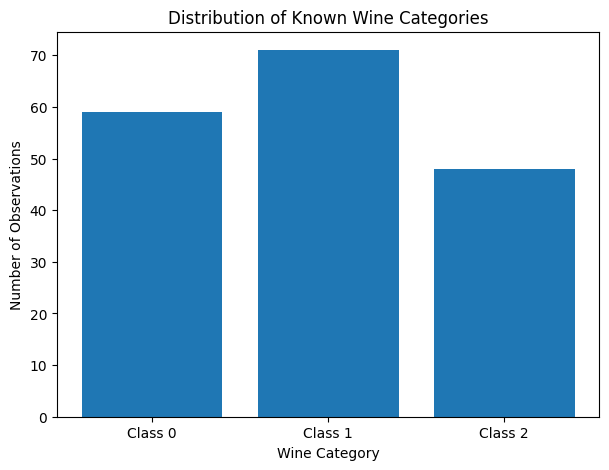

In [6]:
class_counts = actual_classes.value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    [f"Class {class_id}" for class_id in class_counts.index],
    class_counts.values
)

plt.title("Distribution of Known Wine Categories")
plt.xlabel("Wine Category")
plt.ylabel("Number of Observations")

plt.show()

# Known Class Distribution

The three wine categories are reasonably represented in the dataset. The known categories are not used during clustering, but they allow the generated clusters to be evaluated later using Homogeneity and Completeness scores.

In [7]:
scaler = StandardScaler()

scaled_values = scaler.fit_transform(
    feature_data
)

scaled_data = pd.DataFrame(
    scaled_values,
    columns=feature_data.columns
)

scaled_data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


# Feature Standardization

Z-score standardization places all numerical features on a comparable scale. Each transformed feature has a mean close to zero and a standard deviation close to one. This prevents large-valued variables from having an unfair influence on distance calculations.

In [8]:
standardization_check = pd.DataFrame({
    "Feature": scaled_data.columns,
    "Mean": scaled_data.mean().round(4).values,
    "Standard Deviation": scaled_data.std(ddof=0).round(4).values
})

standardization_check

,Feature,Mean,Standard Deviation
0,alcohol,-0.0,1.0
1,malic_acid,-0.0,1.0
2,ash,-0.0,1.0
3,alcalinity_of_ash,-0.0,1.0
4,magnesium,-0.0,1.0
5,total_phenols,0.0,1.0
6,flavanoids,-0.0,1.0
7,nonflavanoid_phenols,0.0,1.0
8,proanthocyanins,-0.0,1.0
9,color_intensity,0.0,1.0


# Standardization Verification

The feature means are approximately zero, and the standard deviations are approximately one. These results verify that the feature scaling process was completed successfully.

In [9]:
pca_model = PCA(
    n_components=2,
    random_state=42
)

pca_coordinates = pca_model.fit_transform(
    scaled_values
)

pca_data = pd.DataFrame(
    pca_coordinates,
    columns=["PC1", "PC2"]
)

print(
    "Variance explained by the first two principal components:",
    round(pca_model.explained_variance_ratio_.sum(), 4)
)

pca_data.head()

Variance explained by the first two principal components: 0.5541


,PC1,PC2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


# PCA Projection

Principal Component Analysis reduces the thirteen-dimensional feature space to two dimensions for visualization. DBSCAN and Hierarchical Clustering still use all thirteen standardized features. PCA is used only to create clear scatter plots.

In [10]:
def evaluate_dbscan(eps_value, minimum_samples):
    model = DBSCAN(
        eps=eps_value,
        min_samples=minimum_samples
    )

    labels = model.fit_predict(
        scaled_values
    )

    noise_mask = labels == -1
    valid_mask = labels != -1

    cluster_count = len(set(labels)) - (
        1 if -1 in labels else 0
    )

    noise_count = int(
        np.sum(noise_mask)
    )

    valid_cluster_count = len(
        np.unique(labels[valid_mask])
    )

    if (
        valid_mask.sum() > 1
        and valid_cluster_count > 1
    ):
        silhouette = silhouette_score(
            scaled_values[valid_mask],
            labels[valid_mask]
        )
    else:
        silhouette = np.nan

    homogeneity = homogeneity_score(
        actual_classes,
        labels
    )

    completeness = completeness_score(
        actual_classes,
        labels
    )

    return {
        "eps": eps_value,
        "min_samples": minimum_samples,
        "clusters": cluster_count,
        "noise_points": noise_count,
        "silhouette": silhouette,
        "homogeneity": homogeneity,
        "completeness": completeness
    }

print("DBSCAN evaluation function created successfully.")

DBSCAN evaluation function created successfully.


# DBSCAN Evaluation Function

The function trains DBSCAN using supplied `eps` and `min_samples` values. It records the number of clusters, number of noise points, Silhouette Score, Homogeneity Score, and Completeness Score. Silhouette is calculated only when DBSCAN forms at least two valid non-noise clusters.

In [11]:
dbscan_results_list = []

for eps_value in [
    1.4,
    1.6,
    1.8,
    2.0,
    2.2,
    2.4
]:
    for minimum_samples in [
        3,
        5,
        7
    ]:
        result = evaluate_dbscan(
            eps_value,
            minimum_samples
        )

        dbscan_results_list.append(result)

dbscan_parameter_table = pd.DataFrame(
    dbscan_results_list
)

dbscan_parameter_table

,eps,min_samples,clusters,noise_points,silhouette,homogeneity,completeness
0,1.4,3,4,165,0.533033,0.075136,0.225388
1,1.4,5,0,178,NaN,0.000000,1.000000
2,1.4,7,0,178,NaN,0.000000,1.000000
3,1.6,3,10,124,0.255357,0.323434,0.279641
4,1.6,5,3,162,0.502071,0.099960,0.270937
5,1.6,7,0,178,NaN,0.000000,1.000000
6,1.8,3,8,90,0.311580,0.532193,0.374657
7,1.8,5,7,118,0.246187,0.354429,0.307376
8,1.8,7,3,156,0.455875,0.139889,0.298149
9,2.0,3,5,64,0.211348,0.442287,0.372380


# DBSCAN Parameter Experiment

The table shows how different combinations of `eps` and `min_samples` influence DBSCAN. Smaller neighborhood settings generally create stricter density requirements and classify more observations as noise. Larger neighborhood settings connect more observations but may merge separate density regions.

In [12]:
valid_dbscan_results = dbscan_parameter_table[
    (dbscan_parameter_table["clusters"] >= 2)
    &
    (dbscan_parameter_table["silhouette"].notna())
].copy()

if valid_dbscan_results.empty:
    raise ValueError(
        "No valid DBSCAN configuration produced at least two clusters. "
        "Add larger eps values and run the parameter experiment again."
    )

ranked_dbscan_results = valid_dbscan_results.sort_values(
    by=["silhouette", "homogeneity"],
    ascending=False
)

ranked_dbscan_results

,eps,min_samples,clusters,noise_points,silhouette,homogeneity,completeness
0,1.4,3,4,165,0.533033,0.075136,0.225388
4,1.6,5,3,162,0.502071,0.099960,0.270937
8,1.8,7,3,156,0.455875,0.139889,0.298149
11,2.0,7,3,110,0.441528,0.428193,0.474721
13,2.2,5,2,55,0.348012,0.410410,0.428216
14,2.2,7,2,63,0.346910,0.372433,0.394076
17,2.4,7,2,42,0.336006,0.460961,0.496043
16,2.4,5,2,36,0.326600,0.504444,0.551868
15,2.4,3,2,28,0.314175,0.487129,0.549122
6,1.8,3,8,90,0.311580,0.532193,0.374657


# DBSCAN Configuration Ranking

Only parameter combinations that formed at least two non-noise clusters were included in the ranking. The configurations were ordered first by Silhouette Score and then by Homogeneity Score.

In [13]:
best_dbscan_result = ranked_dbscan_results.iloc[0]

selected_eps = float(
    best_dbscan_result["eps"]
)

selected_min_samples = int(
    best_dbscan_result["min_samples"]
)

print("Selected eps:", selected_eps)
print("Selected min_samples:", selected_min_samples)
print("Detected clusters:", int(best_dbscan_result["clusters"]))
print("Noise points:", int(best_dbscan_result["noise_points"]))

Selected eps: 1.4
Selected min_samples: 3
Detected clusters: 4
Noise points: 165


# Selected DBSCAN Configuration

The selected `eps` and `min_samples` combination produced the strongest tested internal cluster separation. The output also reports the number of clusters and observations identified as noise.

In [14]:
dbscan_model = DBSCAN(
    eps=selected_eps,
    min_samples=selected_min_samples
)

dbscan_labels = dbscan_model.fit_predict(
    scaled_values
)

dbscan_membership = (
    pd.Series(dbscan_labels)
    .value_counts()
    .sort_index()
    .rename_axis("Cluster Label")
    .reset_index(name="Observation Count")
)

dbscan_membership

,Cluster Label,Observation Count
0,-1,165
1,0,4
2,1,3
3,2,3
4,3,3


# DBSCAN Cluster Membership

The membership table reports the number of observations assigned to each DBSCAN cluster. The cluster label `-1`, when present, identifies observations that DBSCAN classified as noise.

In [15]:
dbscan_valid_mask = dbscan_labels != -1

dbscan_valid_cluster_count = len(
    np.unique(
        dbscan_labels[dbscan_valid_mask]
    )
)

if (
    dbscan_valid_mask.sum() > 1
    and dbscan_valid_cluster_count > 1
):
    dbscan_silhouette = silhouette_score(
        scaled_values[dbscan_valid_mask],
        dbscan_labels[dbscan_valid_mask]
    )
else:
    dbscan_silhouette = np.nan

dbscan_homogeneity = homogeneity_score(
    actual_classes,
    dbscan_labels
)

dbscan_completeness = completeness_score(
    actual_classes,
    dbscan_labels
)

dbscan_metrics = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Homogeneity Score",
        "Completeness Score"
    ],
    "DBSCAN Result": [
        dbscan_silhouette,
        dbscan_homogeneity,
        dbscan_completeness
    ]
})

dbscan_metrics

,Metric,DBSCAN Result
0,Silhouette Score,0.533033
1,Homogeneity Score,0.075136
2,Completeness Score,0.225388


# DBSCAN Evaluation

The Silhouette Score measures the cohesion and separation of the non-noise clusters. Homogeneity measures whether each generated cluster mainly contains observations from one known class. Completeness measures whether observations belonging to the same known class are placed together.

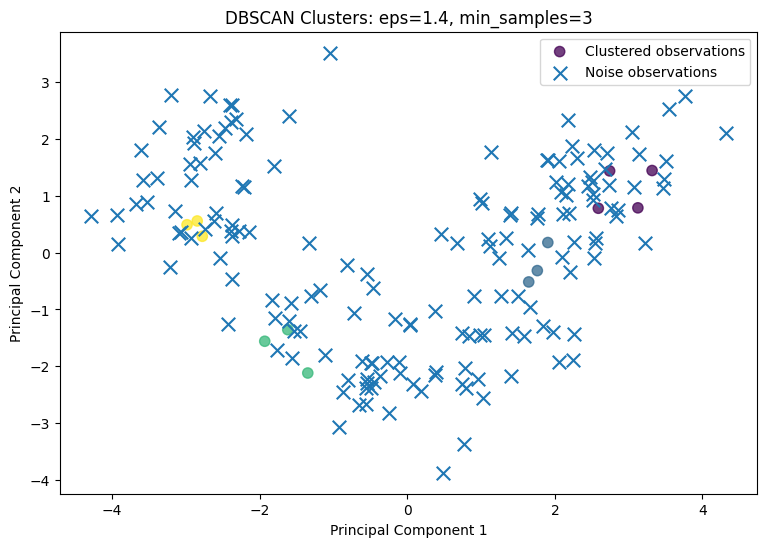

In [16]:
cluster_mask = dbscan_labels != -1
noise_mask = dbscan_labels == -1

plt.figure(figsize=(9, 6))

plt.scatter(
    pca_data.loc[cluster_mask, "PC1"],
    pca_data.loc[cluster_mask, "PC2"],
    c=dbscan_labels[cluster_mask],
    cmap="viridis",
    s=55,
    alpha=0.75,
    label="Clustered observations"
)

plt.scatter(
    pca_data.loc[noise_mask, "PC1"],
    pca_data.loc[noise_mask, "PC2"],
    marker="x",
    s=95,
    label="Noise observations"
)

plt.title(
    f"DBSCAN Clusters: eps={selected_eps}, "
    f"min_samples={selected_min_samples}"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()

# DBSCAN Visualization

The PCA scatter plot displays the density-based cluster assignments. Noise observations are marked separately. This shows that DBSCAN can leave isolated records outside the main groups rather than forcing every observation into a cluster.

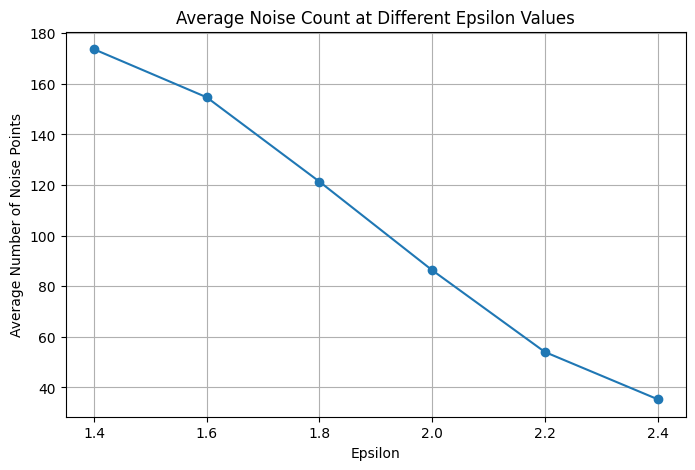

In [17]:
noise_by_epsilon = (
    dbscan_parameter_table
    .groupby("eps")["noise_points"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.plot(
    noise_by_epsilon.index,
    noise_by_epsilon.values,
    marker="o"
)

plt.title("Average Noise Count at Different Epsilon Values")
plt.xlabel("Epsilon")
plt.ylabel("Average Number of Noise Points")
plt.grid(True)

plt.show()

# Effect of Epsilon on Noise

The chart shows how the average number of noise observations changes as `eps` increases. Larger radius values generally connect more observations and reduce noise. However, excessively large values may combine naturally separate groups.

In [18]:
hierarchical_results_list = []

for cluster_count in [
    2,
    3,
    4,
    5,
    6
]:
    model = AgglomerativeClustering(
        n_clusters=cluster_count,
        linkage="ward"
    )

    labels = model.fit_predict(
        scaled_values
    )

    hierarchical_results_list.append({
        "n_clusters": cluster_count,
        "silhouette": silhouette_score(
            scaled_values,
            labels
        ),
        "homogeneity": homogeneity_score(
            actual_classes,
            labels
        ),
        "completeness": completeness_score(
            actual_classes,
            labels
        )
    })

hierarchical_parameter_table = pd.DataFrame(
    hierarchical_results_list
)

hierarchical_parameter_table

,n_clusters,silhouette,homogeneity,completeness
0,2,0.267013,0.444094,0.774489
1,3,0.277444,0.790429,0.782541
2,4,0.225837,0.790429,0.649028
3,5,0.186742,0.810589,0.576247
4,6,0.179666,0.834839,0.552993


# Hierarchical Cluster-Count Experiment

Different values of `n_clusters` were tested to determine how the Agglomerative Clustering solution changes. The Silhouette Score measures internal separation, while Homogeneity and Completeness measure agreement with the known Wine categories.

In [19]:
ranked_hierarchical_results = (
    hierarchical_parameter_table
    .sort_values(
        by=["homogeneity", "silhouette"],
        ascending=False
    )
)

best_hierarchical_result = (
    ranked_hierarchical_results.iloc[0]
)

selected_cluster_count = int(
    best_hierarchical_result["n_clusters"]
)

print(
    "Selected number of hierarchical clusters:",
    selected_cluster_count
)

ranked_hierarchical_results

Selected number of hierarchical clusters: 6


,n_clusters,silhouette,homogeneity,completeness
4,6,0.179666,0.834839,0.552993
3,5,0.186742,0.810589,0.576247
2,4,0.225837,0.790429,0.649028
1,3,0.277444,0.790429,0.782541
0,2,0.267013,0.444094,0.774489


# Hierarchical Model Selection

The selected number of clusters produced the strongest tested agreement with the known categories while maintaining reasonable internal separation. This approach uses evaluation metrics instead of selecting the cluster count only from visual appearance.

In [20]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=selected_cluster_count,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(
    scaled_values
)

hierarchical_membership = (
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
    .rename_axis("Cluster Label")
    .reset_index(name="Observation Count")
)

hierarchical_membership

,Cluster Label,Observation Count
0,0,30
1,1,58
2,2,36
3,3,28
4,4,20
5,5,6


# Hierarchical Cluster Membership

Agglomerative Clustering assigns every wine observation to one of the final clusters. The table shows how the observations were distributed among the selected number of groups.

In [21]:
hierarchical_silhouette = silhouette_score(
    scaled_values,
    hierarchical_labels
)

hierarchical_homogeneity = homogeneity_score(
    actual_classes,
    hierarchical_labels
)

hierarchical_completeness = completeness_score(
    actual_classes,
    hierarchical_labels
)

hierarchical_metrics = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Homogeneity Score",
        "Completeness Score"
    ],
    "Hierarchical Result": [
        hierarchical_silhouette,
        hierarchical_homogeneity,
        hierarchical_completeness
    ]
})

hierarchical_metrics

,Metric,Hierarchical Result
0,Silhouette Score,0.179666
1,Homogeneity Score,0.834839
2,Completeness Score,0.552993


# Hierarchical Evaluation

The selected hierarchical solution is evaluated using the same three measures as DBSCAN. This allows a consistent comparison because both algorithms use the same standardized feature matrix.

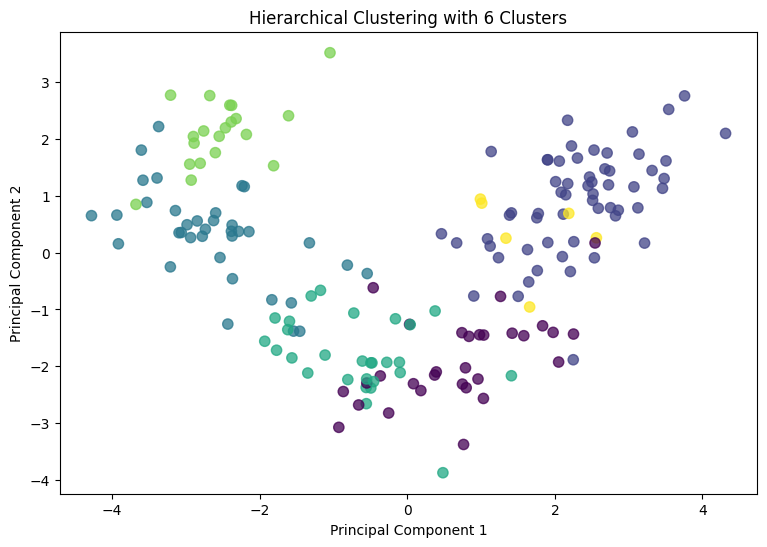

In [22]:
plt.figure(figsize=(9, 6))

plt.scatter(
    pca_data["PC1"],
    pca_data["PC2"],
    c=hierarchical_labels,
    cmap="viridis",
    s=55,
    alpha=0.75
)

plt.title(
    f"Hierarchical Clustering with "
    f"{selected_cluster_count} Clusters"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

# Hierarchical Visualization

The PCA plot illustrates how Agglomerative Clustering partitions the observations. Unlike DBSCAN, the hierarchical algorithm assigns every observation to a cluster and does not produce a separate noise category.

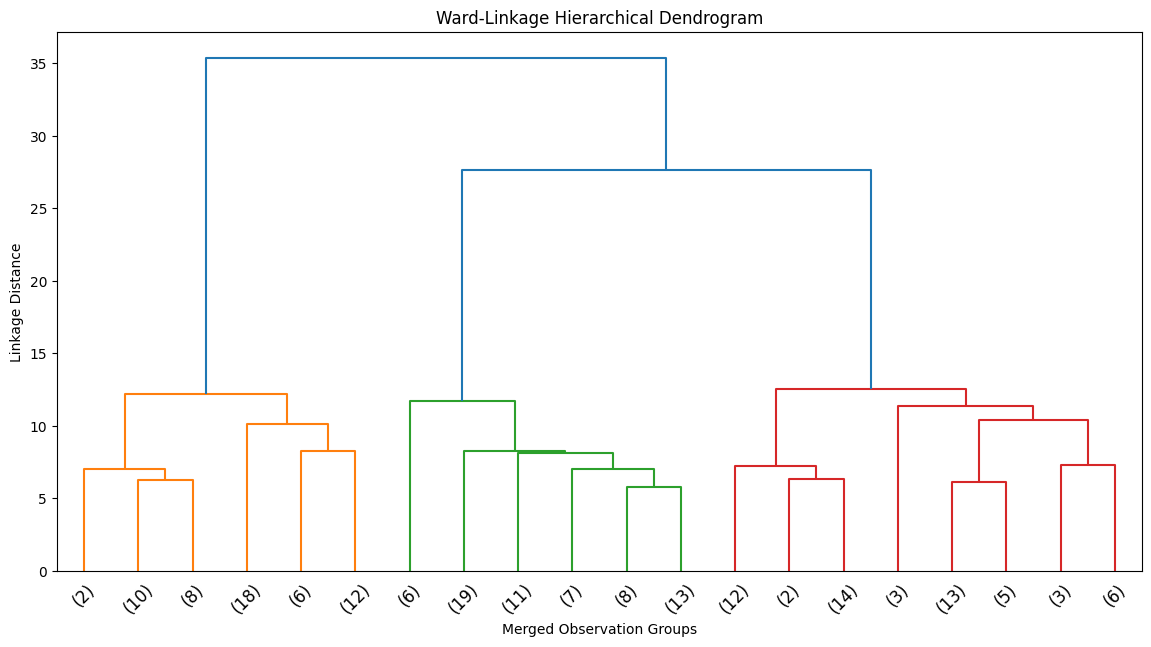

In [23]:
linkage_matrix = linkage(
    scaled_values,
    method="ward"
)

plt.figure(figsize=(14, 7))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=20,
    show_leaf_counts=True,
    leaf_rotation=45
)

plt.title("Ward-Linkage Hierarchical Dendrogram")
plt.xlabel("Merged Observation Groups")
plt.ylabel("Linkage Distance")

plt.show()

# Dendrogram Interpretation

The dendrogram displays the sequence and linkage distance at which observations and clusters were merged. Longer vertical sections represent mergers between more dissimilar groups. A horizontal cut across a major vertical gap can suggest a meaningful number of clusters.

In [24]:
algorithm_comparison = pd.DataFrame({
    "Algorithm": [
        "Agglomerative Hierarchical",
        "DBSCAN"
    ],
    "Silhouette Score": [
        hierarchical_silhouette,
        dbscan_silhouette
    ],
    "Homogeneity Score": [
        hierarchical_homogeneity,
        dbscan_homogeneity
    ],
    "Completeness Score": [
        hierarchical_completeness,
        dbscan_completeness
    ],
    "Noise Points": [
        0,
        int(np.sum(dbscan_labels == -1))
    ]
})

algorithm_comparison

,Algorithm,Silhouette Score,Homogeneity Score,Completeness Score,Noise Points
0,Agglomerative Hierarchical,0.179666,0.834839,0.552993,0
1,DBSCAN,0.533033,0.075136,0.225388,165


# Algorithm Comparison

The table compares internal cluster separation, agreement with the known Wine categories, and noise handling. A higher Silhouette Score indicates better cohesion and separation. Higher Homogeneity and Completeness scores indicate stronger agreement with the known classes.

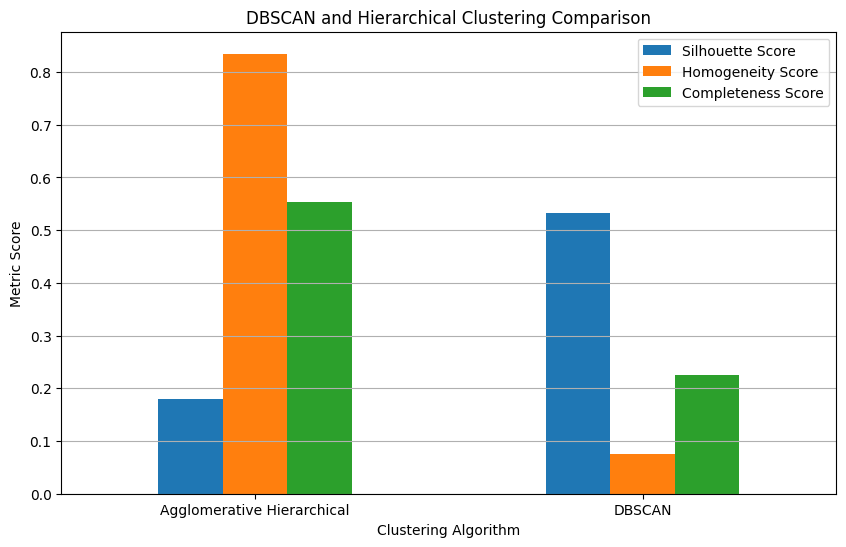

In [25]:
algorithm_comparison.set_index(
    "Algorithm"
)[
    [
        "Silhouette Score",
        "Homogeneity Score",
        "Completeness Score"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("DBSCAN and Hierarchical Clustering Comparison")
plt.xlabel("Clustering Algorithm")
plt.ylabel("Metric Score")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

# Comparative Visualization

The bar chart makes the performance differences easier to observe. All three metrics should be considered together because an algorithm may form internally separated clusters without closely matching the known class structure.

In [26]:
print("LAB 5 FINAL SUMMARY")
print("-------------------")

print("Selected DBSCAN eps:", selected_eps)
print("Selected DBSCAN min_samples:", selected_min_samples)

print(
    "Selected hierarchical cluster count:",
    selected_cluster_count
)

print()

print(
    "DBSCAN Silhouette:",
    round(dbscan_silhouette, 4)
)

print(
    "Hierarchical Silhouette:",
    round(hierarchical_silhouette, 4)
)

print(
    "DBSCAN Homogeneity:",
    round(dbscan_homogeneity, 4)
)

print(
    "Hierarchical Homogeneity:",
    round(hierarchical_homogeneity, 4)
)

print(
    "DBSCAN Completeness:",
    round(dbscan_completeness, 4)
)

print(
    "Hierarchical Completeness:",
    round(hierarchical_completeness, 4)
)

print(
    "DBSCAN Noise Points:",
    int(np.sum(dbscan_labels == -1))
)

LAB 5 FINAL SUMMARY
-------------------
Selected DBSCAN eps: 1.4
Selected DBSCAN min_samples: 3
Selected hierarchical cluster count: 6

DBSCAN Silhouette: 0.533
Hierarchical Silhouette: 0.1797
DBSCAN Homogeneity: 0.0751
Hierarchical Homogeneity: 0.8348
DBSCAN Completeness: 0.2254
Hierarchical Completeness: 0.553
DBSCAN Noise Points: 165


# Final Analysis

This lab compared DBSCAN and Agglomerative Hierarchical Clustering using the standardized Wine dataset. The algorithms produced different cluster structures because they use different definitions of similarity.

DBSCAN formed clusters by identifying dense neighborhoods. The parameter experiment demonstrated that `eps` and `min_samples` strongly affect the number of clusters and noise observations. Smaller neighborhood settings generally produced stricter groupings and more noise, while larger values connected more observations.

Agglomerative Hierarchical Clustering progressively merged similar observations and assigned every record to a final cluster. Testing several cluster counts helped identify a suitable grouping, while the dendrogram provided a visual representation of the hierarchical merging process.

The final comparison uses Silhouette, Homogeneity, and Completeness scores. Silhouette evaluates internal cluster structure, while Homogeneity and Completeness evaluate agreement with the known Wine categories. The actual metric values in the final summary should be used to identify which algorithm performed better.

Hierarchical Clustering is useful when all observations must be assigned and the relationships among groups need to be interpreted. DBSCAN is useful when density-based grouping and explicit noise detection are important.